<a href="https://colab.research.google.com/github/atanasovmi/Quantum-/blob/main/Kopie_von_Bell_state_instructor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# CELL 1: SETUP
# ==========================================
!pip install qiskit[visualization] matplotlib pylatexenc

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

print("✅ Setup Complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 83.8 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=532ed05eb35b56289d2d8c9704d6d0cab76c09b55162c6911e14d0431b86e1e0
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
✅ Setup Complete!


--- Circuit Diagram ---


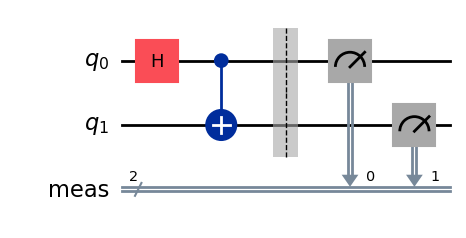

In [ ]:
# ==========================================
# SOLUTION 1: THE BLUEPRINT
# ==========================================

# 1. Initialize a QuantumCircuit with 2 qubits
qc = QuantumCircuit(2)

# 2. Apply H gate to qubit 0 (Superposition)
# This puts Qubit 0 into a state of 50% |0> and 50% |1>
qc.h(0)

# 3. Apply CNOT gate (Entanglement)
# Control is Qubit 0, Target is Qubit 1.
# Logic: "If Q0 is 1, flip Q1."
# Since Q0 is in superposition, this action entangles them.
qc.cx(0, 1)

# 4. Measure all
# This collapses the state so we can see it.
qc.measure_all()

# Draw the circuit
print("--- Circuit Diagram ---")
qc.draw('mpl')

In [ ]:
# ==========================================
# SOLUTION 2: THE EXECUTION
# ==========================================

# 1. Initialize the Sampler (The Simulator)
sampler = StatevectorSampler()

# 2. Run the job
# We pass the circuit as a list.
job = sampler.run([qc])

# 3. Get the result
pub_result = job.result()[0]

# 4. Get the counts
# 'meas' is the default name for the measurement register in measure_all()
counts = pub_result.data.meas.get_counts()

print("--- Raw Statistics ---")
print(f"Counts: {counts}")

--- Raw Statistics ---
Counts: {'11': 530, '00': 494}


--- Visualization ---
Notice how we only see '00' and '11'.
This means the coins always agree, even though they were spinning randomly.


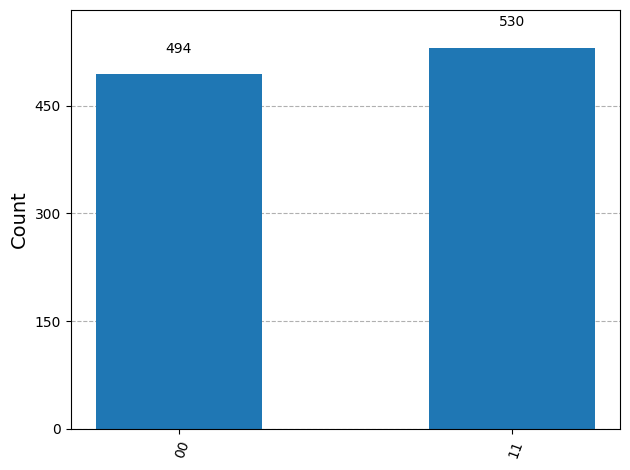

In [ ]:
# ==========================================
# SOLUTION 3: ANALYZE
# ==========================================

print("--- Visualization ---")
print("Notice how we only see '00' and '11'.")
print("This means the coins always agree, even though they were spinning randomly.")
plot_histogram(counts)